Input Shape : (97, 3, 1)
Output Shape: (97,)

Training Simple RNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training LSTM...
Training GRU...

Training Finished!

========== Predictions ==========
Actual Value : 101
RNN  Prediction : 10.74866
LSTM Prediction : 7.288827
GRU  Prediction : 11.816057


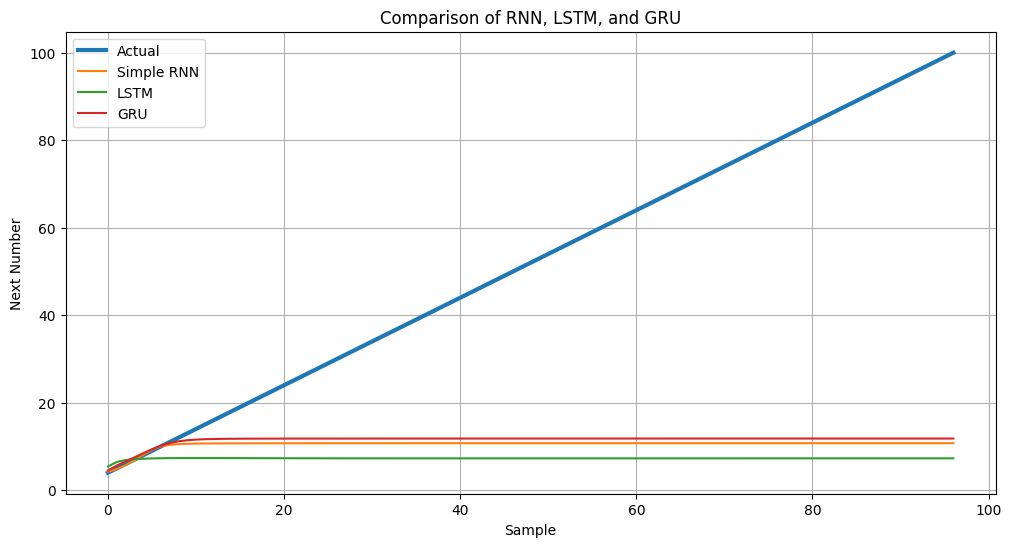

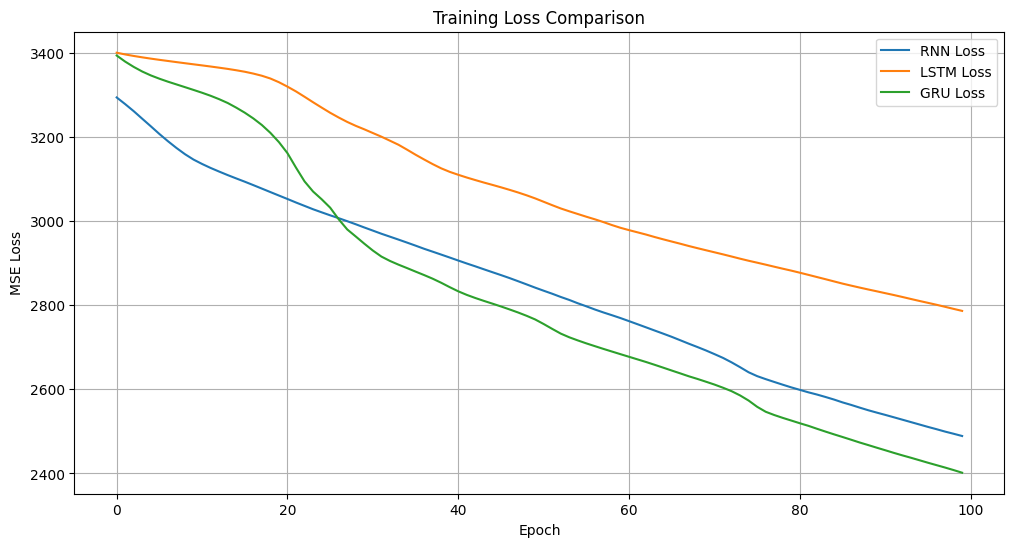

In [1]:
# RNN vs LSTM vs GRU Example
# Predict the next number in a sequence
# ============================================

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense

# ============================================
# Create Dataset
# ============================================

# Sequence from 1 to 100
data = np.arange(1, 101)

window = 3

X = []
y = []

for i in range(len(data) - window):
    X.append(data[i:i + window])
    y.append(data[i + window])

X = np.array(X)
y = np.array(y)

# Reshape to (samples, timesteps, features)
X = X.reshape((X.shape[0], X.shape[1], 1))

print("Input Shape :", X.shape)
print("Output Shape:", y.shape)

# ============================================
# Function to Build Model
# ============================================

def build_model(model_type):

    model = Sequential()

    if model_type == "RNN":
        model.add(SimpleRNN(20, input_shape=(3,1)))

    elif model_type == "LSTM":
        model.add(LSTM(20, input_shape=(3,1)))

    elif model_type == "GRU":
        model.add(GRU(20, input_shape=(3,1)))

    model.add(Dense(1))

    model.compile(
        optimizer='adam',
        loss='mse'
    )

    return model


# ============================================
# Train RNN
# ============================================

print("\nTraining Simple RNN...")

rnn_model = build_model("RNN")

history_rnn = rnn_model.fit(
    X,
    y,
    epochs=100,
    verbose=0
)

# ============================================
# Train LSTM
# ============================================

print("Training LSTM...")

lstm_model = build_model("LSTM")

history_lstm = lstm_model.fit(
    X,
    y,
    epochs=100,
    verbose=0
)

# ============================================
# Train GRU
# ============================================

print("Training GRU...")

gru_model = build_model("GRU")

history_gru = gru_model.fit(
    X,
    y,
    epochs=100,
    verbose=0
)

print("\nTraining Finished!")

# ============================================
# Test Prediction
# ============================================

test = np.array([[98,99,100]])
test = test.reshape((1,3,1))

rnn_prediction = rnn_model.predict(test, verbose=0)
lstm_prediction = lstm_model.predict(test, verbose=0)
gru_prediction = gru_model.predict(test, verbose=0)

print("\n========== Predictions ==========")
print("Actual Value : 101")
print("RNN  Prediction :", rnn_prediction[0][0])
print("LSTM Prediction :", lstm_prediction[0][0])
print("GRU  Prediction :", gru_prediction[0][0])

# ============================================
# Predict Entire Dataset
# ============================================

rnn_pred = rnn_model.predict(X, verbose=0)
lstm_pred = lstm_model.predict(X, verbose=0)
gru_pred = gru_model.predict(X, verbose=0)

# ============================================
# Plot Predictions
# ============================================

plt.figure(figsize=(12,6))

plt.plot(y, label="Actual", linewidth=3)

plt.plot(rnn_pred, label="Simple RNN")

plt.plot(lstm_pred, label="LSTM")

plt.plot(gru_pred, label="GRU")

plt.title("Comparison of RNN, LSTM, and GRU")

plt.xlabel("Sample")

plt.ylabel("Next Number")

plt.legend()

plt.grid(True)

plt.show()

# ============================================
# Plot Training Loss
# ============================================

plt.figure(figsize=(12,6))

plt.plot(history_rnn.history['loss'], label='RNN Loss')

plt.plot(history_lstm.history['loss'], label='LSTM Loss')

plt.plot(history_gru.history['loss'], label='GRU Loss')

plt.title("Training Loss Comparison")

plt.xlabel("Epoch")

plt.ylabel("MSE Loss")

plt.legend()

plt.grid(True)

plt.show()


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [3]:
history_rnn = rnn_model.fit(
    X_train,
    y_train,
    epochs=100,
    validation_data=(X_test, y_test),
    verbose=0
)

In [4]:
from sklearn.metrics import mean_squared_error

rnn_test = rnn_model.predict(X_test, verbose=0)
lstm_test = lstm_model.predict(X_test, verbose=0)
gru_test = gru_model.predict(X_test, verbose=0)

print("RNN MSE :", mean_squared_error(y_test, rnn_test))
print("LSTM MSE:", mean_squared_error(y_test, lstm_test))
print("GRU MSE :", mean_squared_error(y_test, gru_test))

RNN MSE : 5712.67431640625
LSTM MSE: 6957.43359375
GRU MSE : 6224.43359375


In [5]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [6]:
history_rnn = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_test,y_test),
    epochs=100,
    callbacks=[early_stop],
    verbose=0
)

In [7]:
import tensorflow as tf
import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [8]:
from tensorflow.keras.layers import Input

model = Sequential()

model.add(Input(shape=(3,1)))

In [9]:
model.add(SimpleRNN(20))

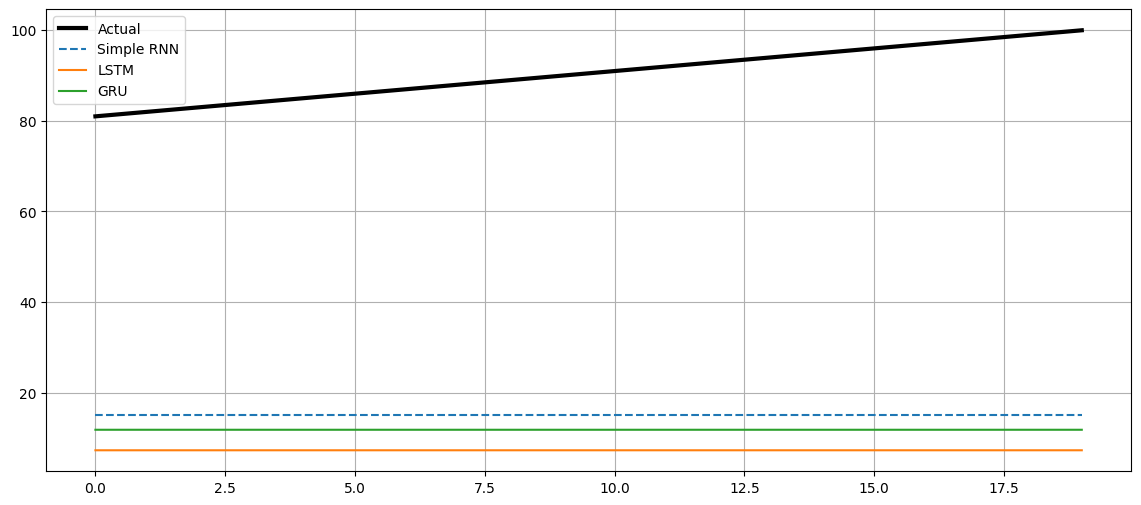

In [10]:
plt.figure(figsize=(14,6))

plt.plot(y_test, color='black', linewidth=3, label='Actual')

plt.plot(rnn_test, '--', label='Simple RNN')

plt.plot(lstm_test, label='LSTM')

plt.plot(gru_test, label='GRU')

plt.legend()
plt.grid(True)

KeyError: 'val_loss'

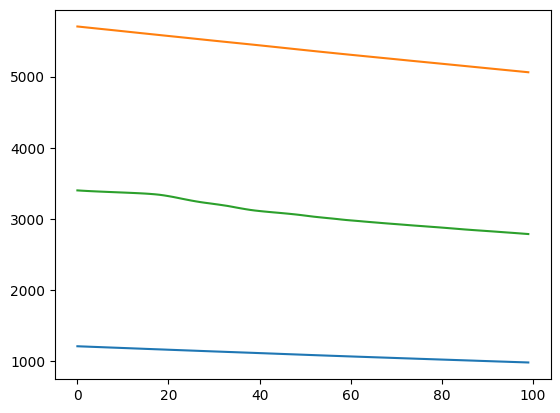

In [11]:
plt.plot(history_rnn.history['loss'], label='RNN Train')
plt.plot(history_rnn.history['val_loss'], label='RNN Val')

plt.plot(history_lstm.history['loss'], label='LSTM Train')
plt.plot(history_lstm.history['val_loss'], label='LSTM Val')

plt.plot(history_gru.history['loss'], label='GRU Train')
plt.plot(history_gru.history['val_loss'], label='GRU Val')

In [12]:
print("\n===============================")
print("Model\t\tMSE")
print("===============================")
print(f"Simple RNN\t{mean_squared_error(y_test,rnn_test):.4f}")
print(f"LSTM\t\t{mean_squared_error(y_test,lstm_test):.4f}")
print(f"GRU\t\t{mean_squared_error(y_test,gru_test):.4f}")


Model		MSE
Simple RNN	5712.6743
LSTM		6957.4336
GRU		6224.4336


In [13]:
print("\n========== Predictions ==========")
print("Actual Value : 101")
print("RNN  Prediction :", rnn_prediction[0][0])
print("LSTM Prediction :", lstm_prediction[0][0])
print("GRU  Prediction :", gru_prediction[0][0])


========== Predictions ==========
Actual Value : 101
RNN  Prediction : 10.74866
LSTM Prediction : 7.288827
GRU  Prediction : 11.816057


In [14]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

data = np.arange(1, 101).reshape(-1, 1)
data = scaler.fit_transform(data).flatten()

In [15]:
test = scaler.transform(np.array([[98], [99], [100]])).reshape(1, 3, 1)

prediction = model.predict(test)

prediction = scaler.inverse_transform(prediction)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 614ms/step
[[ 15.327415    33.22501     76.01015     34.486168    35.844135
   -7.1922555  -13.775709    21.808844   -39.509193     9.861154
   30.994333   -30.705631    42.9941      16.250652   -36.398556
  -29.836575    27.648233    25.213263     0.47428852   3.336033  ]]
